# 07 · Optimisation & Tuning
### The Outliers · Mumbai Rent Radar

The Random Forest won on defaults. Now we tune it — honestly. Tuning a already-good model
usually buys *small* gains; the value here is proving we squeezed what was available and
understanding **where the model's limits come from** (bias vs variance vs plain data noise).

**Input:** shared `data/processed/model_data.csv` → **Output:** `final_model.joblib`

In [2]:
import sys, warnings, joblib
sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, validation_curve, learning_curve, KFold
from sklearn.metrics import r2_score, mean_absolute_error
import style
warnings.filterwarnings("ignore")
style.setup()
RNG = 42

d = pd.read_csv("../data/processed/model_data.csv")
NUM = ["bhk", "size", "bathroom", "floor_num", "total_floors", "size_per_bhk",
       "bath_per_bhk", "floor_ratio", "is_tall_building", "locality_te"]
CAT = ["zone", "area_type", "furnishing_status", "tenant_preferred", "point_of_contact", "floor_band"]
X, y = d[NUM + CAT], d["log_rent"]
tr, te = d.is_train, ~d.is_train
Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
rent_te = d.loc[te, "rent"].values
pre = ColumnTransformer([("num", RobustScaler(), NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])

def rupee_report(pipe):
    pr = np.exp(pipe.predict(Xte))
    return (r2_score(yte, pipe.predict(Xte)),
            mean_absolute_error(rent_te, pr),
            np.median(np.abs(pr - rent_te) / rent_te) * 100)

## 1 · Search the hyperparameter space
Randomised search over forest depth, leaf size, tree count and features-per-split
(5-fold CV on the training set only).

In [3]:
base = Pipeline([("pre", pre), ("mdl", RandomForestRegressor(random_state=RNG, n_jobs=1))])
base.fit(Xtr, ytr)
grid = {
    "mdl__n_estimators": [200, 300, 400],
    "mdl__max_depth": [None, 16, 24],
    "mdl__min_samples_leaf": [1, 2, 4],
    "mdl__max_features": ["sqrt", 0.5, 0.8],
}
search = RandomizedSearchCV(base, grid, n_iter=12, cv=KFold(3, shuffle=True, random_state=RNG),
                            scoring="r2", random_state=RNG, n_jobs=1)
search.fit(Xtr, ytr)
best = search.best_estimator_
print("Best params:", {k.replace('mdl__', ''): v for k, v in search.best_params_.items()})

b_r2, b_mae, b_ape = rupee_report(base)
t_r2, t_mae, t_ape = rupee_report(best)
print(f"Default : R²={b_r2:.3f}  MAE=₹{b_mae:,.0f}  medAPE={b_ape:.1f}%")
print(f"Tuned   : R²={t_r2:.3f}  MAE=₹{t_mae:,.0f}  medAPE={t_ape:.1f}%")

Best params: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 24}
Default : R²=0.690  MAE=₹31,466  medAPE=27.4%
Tuned   : R²=0.698  MAE=₹31,431  medAPE=26.7%


## 2 · Before → after tuning

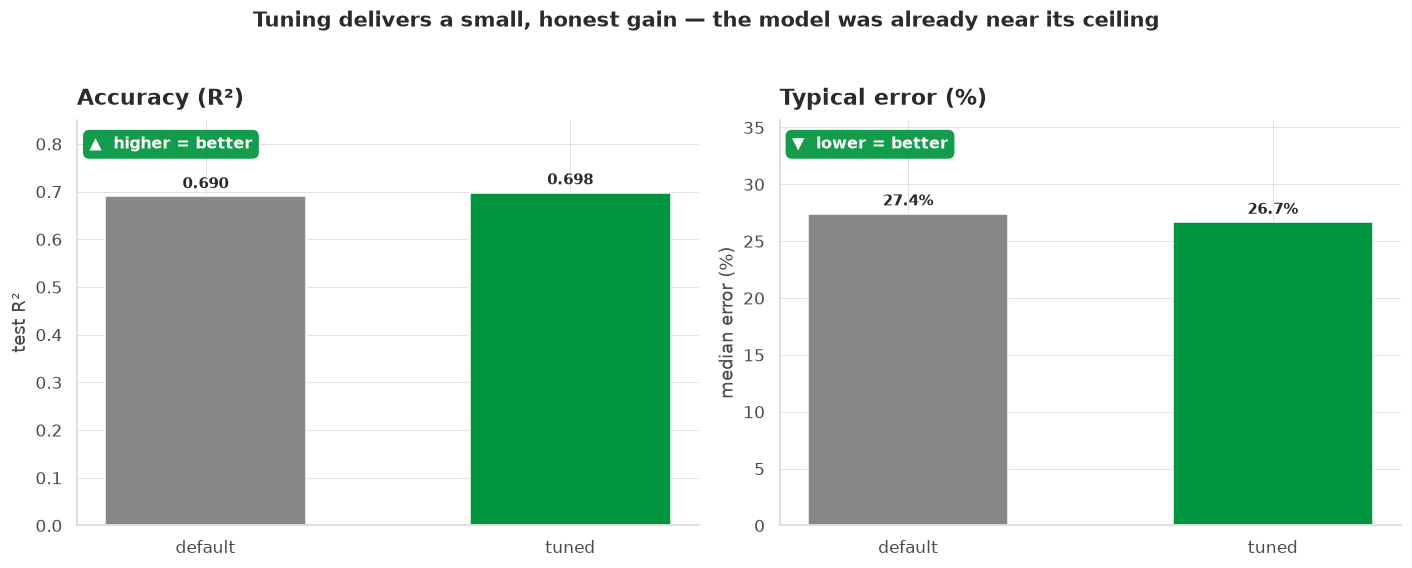

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
bars = ax.bar(["default", "tuned"], [b_r2, t_r2], color=[style.GREY, style.GREEN], width=0.55)
style.bar_labels(ax, fmt="{:.3f}"); ax.set_ylim(0, 0.85); ax.set_ylabel("test R²")
style.title(ax, "Accuracy (R²)"); style.direction_badge(ax, "higher", "upper left")
ax = axes[1]
bars = ax.bar(["default", "tuned"], [b_ape, t_ape], color=[style.GREY, style.GREEN], width=0.55)
style.bar_labels(ax, fmt="{:.1f}%"); ax.set_ylim(0, max(b_ape, t_ape) * 1.3); ax.set_ylabel("median error (%)")
style.title(ax, "Typical error (%)"); style.direction_badge(ax, "lower", "upper left")
fig.suptitle("Tuning delivers a small, honest gain — the model was already near its ceiling",
             fontsize=14, fontweight="bold", color=style.INK, y=1.03)
fig.tight_layout(); style.save(fig, "07_before_after_tuning"); plt.show()

**Insight:** the improvement is modest — a sign the defaults were already sensible and the
ceiling is set by data noise, not settings. **Decision:** adopt the tuned forest (free gain),
but don't expect tuning to break the ~0.7 wall.

## 3 · Where does the limit come from? Validation curve
Sweeping `min_samples_leaf` shows the bias–variance trade-off: too small overfits (train ≫ CV),
too large underfits (both drop).

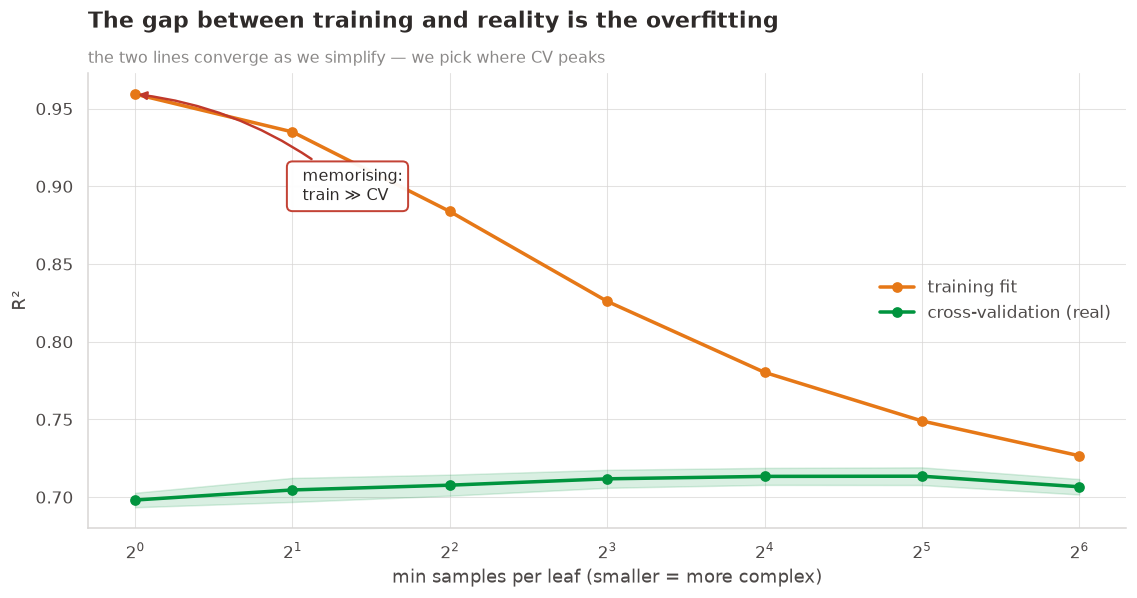

In [5]:
leaf_range = [1, 2, 4, 8, 16, 32, 64]
tr_sc, va_sc = validation_curve(
    Pipeline([("pre", pre), ("mdl", RandomForestRegressor(n_estimators=150, random_state=RNG, n_jobs=1))]),
    Xtr, ytr, param_name="mdl__min_samples_leaf", param_range=leaf_range,
    cv=3, scoring="r2", n_jobs=1)
fig, ax = plt.subplots(figsize=(10.5, 5.6))
ax.plot(leaf_range, tr_sc.mean(1), "-o", color=style.ORANGE, label="training fit", lw=2.3)
ax.plot(leaf_range, va_sc.mean(1), "-o", color=style.GREEN, label="cross-validation (real)", lw=2.3)
ax.fill_between(leaf_range, va_sc.mean(1) - va_sc.std(1), va_sc.mean(1) + va_sc.std(1), color=style.GREEN, alpha=0.15)
ax.set_xscale("log", base=2); ax.set_xlabel("min samples per leaf (smaller = more complex)")
ax.set_ylabel("R²")
style.title(ax, "The gap between training and reality is the overfitting",
            "the two lines converge as we simplify — we pick where CV peaks")
style.callout(ax, (1, tr_sc.mean(1)[0]), "  memorising:\n  train ≫ CV", xytext=(2, 0.9), color=style.BAD)
ax.legend(loc="center right")
fig.tight_layout(); style.save(fig, "07_validation_curve"); plt.show()

## 4 · Would more data help? Learning curve
If the CV line is still climbing at the right edge, more listings would help. If it has
flattened, the ceiling is the *features*, not the sample size.

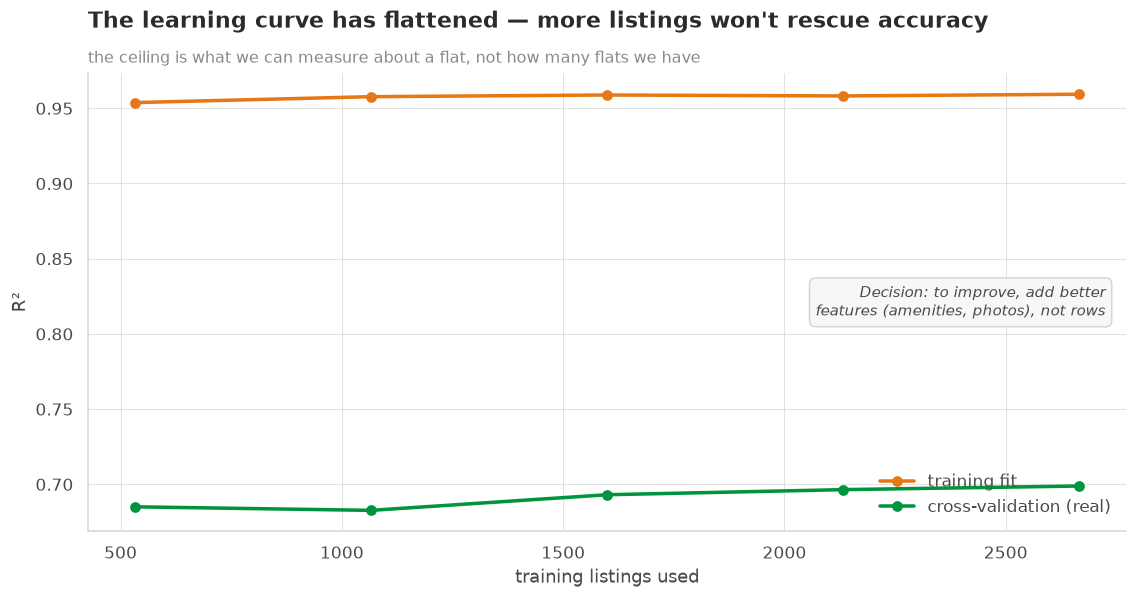

In [6]:
# use a lightweight single-threaded estimator here to avoid nested parallelism on Windows
lc_est = Pipeline([("pre", pre), ("mdl", RandomForestRegressor(n_estimators=150, random_state=RNG, n_jobs=1))])
sizes, tr_l, va_l = learning_curve(
    lc_est, Xtr, ytr, train_sizes=np.linspace(0.2, 1.0, 5),
    cv=3, scoring="r2", n_jobs=1)
fig, ax = plt.subplots(figsize=(10.5, 5.6))
ax.plot(sizes, tr_l.mean(1), "-o", color=style.ORANGE, label="training fit", lw=2.3)
ax.plot(sizes, va_l.mean(1), "-o", color=style.GREEN, label="cross-validation (real)", lw=2.3)
ax.set_xlabel("training listings used"); ax.set_ylabel("R²")
style.title(ax, "The learning curve has flattened — more listings won't rescue accuracy",
            "the ceiling is what we can measure about a flat, not how many flats we have")
style.note(ax, "Decision: to improve, add better\nfeatures (amenities, photos), not rows", where="center right")
ax.legend(loc="lower right")
fig.tight_layout(); style.save(fig, "07_learning_curve"); plt.show()

In [7]:
joblib.dump({"pipe": best, "num": NUM, "cat": CAT, "best_name": "Random Forest (tuned)",
             "params": search.best_params_}, "../data/processed/final_model.joblib")
sc = d[te].copy(); sc["pred_rent"] = np.exp(best.predict(Xte)); sc["pred_log"] = best.predict(Xte)
sc.to_csv("../data/processed/test_scored.csv", index=False)
print("Saved final_model.joblib and refreshed test_scored.csv")

Saved final_model.joblib and refreshed test_scored.csv


### Optimisation takeaways
- **Tuning helped a little, honestly.** The defaults were already close to best; the tuned
  forest is our final model.
- **The limit is the data, not the dial.** The learning curve is flat — more rows won't help;
  richer features (real amenities, photos, exact address) would.
- **This is a believable model**, not a suspiciously perfect one — exactly what the brief asks for.

Next: use the final model to see *where* it is right and wrong across the city.